# ONERA 468 CRM Data Exploration

End-to-end notebook for the ONERA 468 CRM Codabench challenge.
Covers: data loading, train/test split visualization, 3-D density field
rendering, KNN baseline training, extended error metrics, and residual
KL-divergence analysis.

## 1. Imports

In [2]:
#srun --account=tau --partition=gpu-best --nodes=1 --ntasks=1 --cpus-per-task=10 --gres=gpu:1 --mem=64G --time=18:00:00 --pty bash

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, entropy
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


## 2. Global Constants

Column indices into the 9-feature input array and mesh-level constants
shared across all analysis sections.

In [2]:
nwallp           = 260774   # wall points per simulation
COL_MINF         = 6        # Mach number column
COL_AOA          = 7        # angle of attack column
COL_PI           = 8        # tunnel pressure ratio column
DATA_DIR         = 'data/'

#DATA_DIR         = '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'


## 6. KNN Baseline: Phase 1 & 2 Evaluation

Loads train and test arrays for both Codabench phases, trains a 5-NN regressor
on (Mach, AoA, Pi) condition vectors, and predicts the density field for each phase.

In [3]:
print('Loading data...')
X_train = np.load(DATA_DIR + 'splitv2/train_data.npy')
y_train = np.load(DATA_DIR + 'splitv2/train_labels.npy')
X_test1 = np.load(DATA_DIR + 'splitv2/test_phase1_data.npy')
y_test1 = np.load(DATA_DIR+'splitv2/test_phase1_labels.npy')
X_test2 = np.load(DATA_DIR + 'splitv2/test_phase2_data.npy')
y_test2 = np.load(DATA_DIR+'splitv2/test_phase2_labels.npy')

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]
test1_conds = X_test1[::nwallp, COL_MINF:COL_PI+1]
test2_conds = X_test2[::nwallp, COL_MINF:COL_PI+1]

n_train = X_train.shape[0] // nwallp
n_test1 = X_test1.shape[0] // nwallp
n_test2 = X_test2.shape[0] // nwallp

#meth1
test1_weights = np.where(np.abs(test1_conds[:, 1]) < 10.0, 1.0, 0.5)
test2_weights = np.where(np.abs(test2_conds[:, 1]) < 10.0, 1.0, 0.5)

# #meth2, what is the difference? à voir après...
# epsilon=10e-6
# confidenceScore = 1.
# if (AoA<=-10.+epsilon) or (AoA>=10.-epsilon) : confidenceScore = .5

scaler         = StandardScaler()
train_conds_sc = scaler.fit_transform(train_conds)
test1_conds_sc = scaler.transform(test1_conds)
test2_conds_sc = scaler.transform(test2_conds)

print('Training KNN...')
knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn.fit(train_conds_sc, y_train.reshape(n_train, nwallp))

print('Predicting phase 1...')
y_pred1 = knn.predict(test1_conds_sc).reshape(-1)
print('Predicting phase 2...')
y_pred2 = knn.predict(test2_conds_sc).reshape(-1)

GLOBAL_MEAN_RHO = float(np.mean(y_train))
SIGMA_REF_GLOBAL = 0.01 * GLOBAL_MEAN_RHO


Loading data...
Training KNN...
Predicting phase 1...
Predicting phase 2...


## 7. Component Metrics wrMAE, R2, Weighted KL

Loads component labels and, per phase, computes per-simulation wrMAE, R2
and a component-weighted KL score together. The weighted KL replaces a single
global score with a weighted sum of per-component `residual_kl_normal` scores:
wing=0.3, pylon=0.3, fuselage=0.2, nacelle=0.2.

In [4]:
component_labels = np.load(DATA_DIR + 'component_labels_unique.npy')
with open(DATA_DIR + 'component_map.json') as f:
    component_map = {int(k): v for k, v in json.load(f).items()}

KL_WEIGHTS = {'wing': 0.3, 'pylon': 0.3, 'fuselage': 0.2, 'nacelle': 0.2}
comp_masks = {cname: component_labels == cid for cid, cname in component_map.items()}


## 8. Residual KL-Divergence

`residual_kl_normal` measures how close the residual distribution is to a narrow
reference Gaussian N(0, 0.1*sigma_y) -- a proxy for perfect prediction.
score = exp(-KL) in (0, 1]; higher is better.

In [5]:
def residual_kl_normal(y_true, y_pred, sigma_ref, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref = sigma_ref_frac * sigma_y.
    Returns KL, score=1/(1+KL), normalised bias and spread.
    """
    eps       = y_pred - y_true
    sigma_y   = y_true.std() + 1e-12

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(1.0 / (1.0 + kl)),
            'bias': float(np.mean(eps) / sigma_y), 'spread': float(np.std(eps) / sigma_y)}

def residual_kl_weighted(y_true, y_pred, comp_masks, comp_weights, sigma_ref, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) on residuals pooled across components,
    with each point weighted by its component weight (so wing/pylon points
    count more than fuselage/nacelle points in the SAME histogram).
    Single shared sigma_y -> comparable across all simulations.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    sample_weight = np.zeros_like(eps)
    for cname, mask in comp_masks.items():
        sample_weight[mask] = comp_weights.get(cname, 0.0)

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]

    p, _ = np.histogram(eps, bins=bins, weights=sample_weight, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q = np.clip(q, 1e-10, None)
    q /= q.sum()

    kl = float(entropy(p, q))
    bias   = float(np.average(eps, weights=sample_weight)) / sigma_y
    spread = float(np.sqrt(np.average((eps - eps.mean())**2, weights=sample_weight))) / sigma_y
    return {'kl': kl, 'score': float(1.0 / (1.0 + kl)), 'bias': bias, 'spread': spread}

In [6]:
# ---------------------------------------------------------------------------
# Core metrics: R2 and rMAE (relative MAE)
# ---------------------------------------------------------------------------

def compute_R2(y, yhat, confidence_pointwise):
    """Confidence-weighted R^2 score."""
    ymean = np.mean(y)
    SSE   = np.sum(confidence_pointwise * (y - yhat) ** 2)    # weighted residual sum of squares
    SSD   = np.sum(confidence_pointwise * (y - ymean) ** 2)   # weighted total sum of squares
    return float(1.0 - SSE / SSD)


def compute_worst_rMAE(y, yhat, confidence_per_case):
    """
    Compute the per-case relative MAE (rMAE) on high-confidence cases only,
    then return the index and value of the worst (max) one.
    """
    rMAE_list, idx_list = [], []
    for l in range(len(confidence_per_case)):
        if confidence_per_case[l] < 1.0:
            continue  # skip low-confidence cases entirely
        ycase    = y[l * nwallp:(l + 1) * nwallp]
        yhatcase = yhat[l * nwallp:(l + 1) * nwallp]
        rMAE_list.append(np.mean(np.abs(ycase - yhatcase)) / np.mean(np.abs(ycase)))
        idx_list.append(l)
    rMAE_arr    = np.array(rMAE_list)
    iworst_local = int(np.argmax(rMAE_arr))  # worst = highest rMAE
    return idx_list[iworst_local], float(rMAE_arr[iworst_local])


# ---------------------------------------------------------------------------
# Bootstrap confidence interval, resampled directly from existing predictions
# (no re-prediction, so this stays cheap)
# ---------------------------------------------------------------------------

def _bootstrap_ci(values, stat_func=np.max, n_boot=1000, ci=95, rng=None):
    """Percentile bootstrap CI for stat_func over an existing 1-D array of values."""
    rng = rng or np.random.default_rng()
    n = len(values)
    idx = rng.integers(0, n, size=(n_boot, n))          # n_boot resamples of size n
    boot_stats = stat_func(values[idx], axis=1)          # stat computed per resample
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boot_stats, [alpha, 100 - alpha])
    return float(lo), float(hi)


# ---------------------------------------------------------------------------
# Per-phase evaluation: pooled R2 / worst rMAE, plus per-component rMAE and KL
# ---------------------------------------------------------------------------

def     evaluate_phase(y, y_pred, weights, n_sims, nwallp, sigma_ref):
    """Pooled worst-rMAE/R2 (challenge metrics) plus per-simulation component KL and R2."""
    Y, Yh = y.reshape(n_sims, nwallp), y_pred.reshape(n_sims, nwallp)
    confidence_pointwise = np.repeat(weights, nwallp)

    iworst, worst_rMAE = compute_worst_rMAE(y, y_pred, weights)
    r2_global = compute_R2(y, y_pred, confidence_pointwise)

    comp_r2         = {}                                             # pooled R2 per component
    comp_r2_persim  = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}  # per-sim R2, for bootstrap
    comp_rMAE = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}
    comp_kl   = {c: [None] * n_sims for c in KL_WEIGHTS}
    kl_w      = np.full(n_sims, np.nan)
    valid_idx = np.where(weights == 1.0)[0]

    # pooled R2 per component, across all simulations at once
    for cname, mask in comp_masks.items():
        if cname not in KL_WEIGHTS:
            continue
        full_mask = np.tile(mask, n_sims)
        comp_r2[cname] = compute_R2(y[full_mask], y_pred[full_mask], confidence_pointwise[full_mask])

    # per-simulation, per-component rMAE, R2 and KL (only for valid/high-confidence sims)
    for i in valid_idx:
        yc, yhatc = Y[i], Yh[i]
        for cname, mask in comp_masks.items():
            if cname not in KL_WEIGHTS:
                continue
            ycm, yhatcm = yc[mask], yhatc[mask]
            comp_rMAE[cname][i]      = np.mean(np.abs(ycm - yhatcm)) / np.mean(np.abs(ycm))
            comp_r2_persim[cname][i] = compute_R2(ycm, yhatcm, np.ones_like(ycm))  # unweighted, single sim
            comp_kl[cname][i]        = residual_kl_normal(ycm, yhatcm, sigma_ref)
        kl_w[i] = residual_kl_weighted(yc, yhatc, comp_masks, KL_WEIGHTS, sigma_ref)['kl']

    return dict(Y=Y, Yh=Yh, iworst=iworst, worst_rMAE=worst_rMAE, r2=r2_global, kl=kl_w,
                comp_rMAE=comp_rMAE, comp_r2=comp_r2, comp_r2_persim=comp_r2_persim, comp_kl=comp_kl)


# ---------------------------------------------------------------------------
# Printing helpers
# ---------------------------------------------------------------------------

def _print_table(title, comp_dict_pooled, comp_dict_persim, fmt, n_boot=1000, ci=95):
    """Print pooled value per component plus a bootstrap CI from per-sim values (e.g. R2)."""
    print(f'\n  {title}')
    print(f'  {"component":<10}  {"pooled":>9}  {f"{ci}% CI":>19}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}')
    for cname in KL_WEIGHTS:
        vals = comp_dict_persim[cname]
        vals = vals[~np.isnan(vals)]           # drop low-confidence / skipped sims
        lo, hi = _bootstrap_ci(vals, np.mean, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {comp_dict_pooled[cname]:>9{fmt}}  [{lo:>7{fmt}}, {hi:>7{fmt}}]')


def _print_table_per_sim(title, comp_dict, fmt, n_boot=1000, ci=95):
    """
    Print the worst (max) per-simulation value per component, with a
    bootstrap confidence interval around that worst value.
    """
    print(f'\n  {title}')
    print(f'  {"component":<10}  {"worst":>9}  {f"{ci}% CI":>19}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}')
    for cname in KL_WEIGHTS:
        vals = comp_dict[cname]
        vals = vals[~np.isnan(vals)]           # drop low-confidence sims (left as NaN)
        worst  = np.max(vals)
        lo, hi = _bootstrap_ci(vals, np.max, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {worst:>9{fmt}}  [{lo:>7{fmt}}, {hi:>7{fmt}}]')


def _print_kl_table(comp_kl, n_boot=1000, ci=95):
    """Print mean/max KL, mean score, mean bias, mean spread per component, with a CI on mean KL."""
    print(f'\n  KL by component')
    print(f'  {"component":<10}  {"mean KL":>9}  {f"{ci}% CI":>19}  {"max KL":>9}  {"mean score":>10}  {"mean bias":>10}  {"mean spread":>11}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*19}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
    for cname in KL_WEIGHTS:
        vals = [v for v in comp_kl[cname] if v is not None]  # drop skipped (low-confidence) sims
        kl_c, sc_c, bi_c, sp_c = (np.array([v[k] for v in vals]) for k in ('kl', 'score', 'bias', 'spread'))
        lo, hi = _bootstrap_ci(kl_c, np.mean, n_boot=n_boot, ci=ci)
        print(f'  {cname:<10}  {kl_c.mean():>9.4f}  [{lo:>7.4f}, {hi:>7.4f}]  {kl_c.max():>9.4f}  '
              f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')


def print_phase_summary(label, res):
    """Print the full summary block for one phase (worst-case + component tables)."""
    i_mae = res['iworst']                       # sim index with the globally worst rMAE
    i_kl  = int(np.nanargmax(res['kl']))         # sim index with the worst weighted KL

    # single-value rMAE for the worst-KL sim (not the aggregated worst_rMAE)
    rMAE_at_worst_kl = np.mean(np.abs(res['Y'][i_kl] - res['Yh'][i_kl])) / np.mean(np.abs(res['Y'][i_kl]))

    print(f'\n{label}')
    print(f'  worst rMAE: sim {i_mae}  rMAE={res["worst_rMAE"]:.4f}  KL={res["kl"][i_mae]:.4f}  score={1.0/(1.0+res["kl"][i_mae]):.4f}')
    print(f'  worst KL  : sim {i_kl}  KL={res["kl"][i_kl]:.4f}  score={1.0/(1.0+res["kl"][i_kl]):.4f}  rMAE={rMAE_at_worst_kl:.4f}')

    _print_table_per_sim('rMAE by component (worst + bootstrap CI)', res['comp_rMAE'], '.4f')
    _print_table('R2 by component (pooled)', res['comp_r2'], res['comp_r2_persim'], '.4f')
    _print_kl_table(res['comp_kl'])

    # drop sims where KL is NaN (skipped low-confidence sims) before aggregating
    kl_global    = res['kl'][~np.isnan(res['kl'])]
    score_global = 1.0 / (1.0 + kl_global)
    print(f'\n  Global weighted KL: mean={kl_global.mean():.4f}  max={kl_global.max():.4f}  mean score={score_global.mean():.4f}')


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------

res1 = evaluate_phase(y_test1, y_pred1, test1_weights, n_test1, nwallp, SIGMA_REF_GLOBAL)
res2 = evaluate_phase(y_test2, y_pred2, test2_weights, n_test2, nwallp, SIGMA_REF_GLOBAL)

for label, res in [('Phase 1', res1), ('Phase 2', res2)]:
    print_phase_summary(label, res)


Phase 1
  worst rMAE: sim 131  rMAE=0.0340  KL=4.1089  score=0.1957
  worst KL  : sim 110  KL=4.9179  score=0.1690  rMAE=0.0322

  rMAE by component (worst + bootstrap CI)
  component       worst               95% CI
  ──────────  ─────────  ───────────────────
  wing           0.0623  [ 0.0518,  0.0623]
  pylon          0.0719  [ 0.0566,  0.0719]
  fuselage       0.0266  [ 0.0246,  0.0266]
  nacelle        0.0264  [ 0.0258,  0.0264]

  R2 by component (pooled)
  component      pooled               95% CI
  ──────────  ─────────  ───────────────────
  wing           0.9425  [ 0.9344,  0.9426]
  pylon          0.9444  [ 0.9110,  0.9293]
  fuselage       0.9605  [ 0.9572,  0.9660]
  nacelle        0.9894  [ 0.9883,  0.9898]

  KL by component
  component     mean KL               95% CI     max KL  mean score   mean bias  mean spread
  ──────────  ─────────  ───────────────────  ─────────  ──────────  ──────────  ───────────
  wing           4.2030  [ 3.9423,  4.4803]     7.4844      0.

## 9. Worst-Condition Plots (Same Error Scale) and Worst-KL Histograms

3-D scatter of ground truth / prediction / absolute error for the worst-wrMAE
and worst-weighted-KL simulation in each phase, plus the true pointwise mean field
across all simulations (mean of y and y_pred at each of the nwallp points).
Error plots share one color scale across both phases for direct comparison.
Residual histograms per body part are shown for the worst-KL simulation.

In [9]:
def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE, phase_label, elev, r2=None, err_vmax=None):
    """3-D scatter of ground truth, prediction and absolute error for one simulation."""
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, COL_MINF]
    AoA  = X_worst[0, COL_AOA]
    Pi   = X_worst[0, COL_PI]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]
    error   = np.abs(y_worst - yhat_worst)

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction rho', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    r2_str = f'  R2={r2:.4f}' if r2 is not None else ''
    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{phase_label}] Worst condition (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  wrMAE={wrMAE:.4f}{r2_str}',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')
        fmin, fmax = _scale(field)
        if col == 2 and err_vmax is not None:
            fmin, fmax = 0.0, err_vmax
        sca = ax.scatter3D(X_coord, Y_coord, Z_coord,
                           c=field, vmin=fmin, vmax=fmax,
                           cmap=cmap, s=0.3, alpha=0.8)
        ax.view_init(elev=elev, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'worst_condition_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


In [10]:
import torch
import torch.nn as nn

SEED      = 0


class GlobalMLP(nn.Module):
    def __init__(self, n_out, hidden, dropout=0.0, mean_field=None):
        super().__init__()
        layers, d = [], 3
        for h in hidden:
            layers += [nn.Linear(d, h), nn.LeakyReLU(0.01)]
            if dropout > 0.0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)
        mf = torch.zeros(n_out) if mean_field is None else torch.tensor(mean_field, dtype=torch.float32)
        self.register_buffer('mean_field', mf)

    def forward(self, c):
        return self.mean_field + self.net(c)

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [ ]:
# ckpt = torch.load('FILES_RHO_ALL_POINTS_reduitfloat32/mlp_klw.pt', map_location=device, weights_only=False)
ckpt = torch.load('FILES_RHO_ALL_POINTS_reduitfloat32/mlp_klw_globalref.pt', map_location=device, weights_only=False)

model = GlobalMLP(ckpt['nwallp'], ckpt['hidden'], dropout=ckpt.get('dropout', 0.0)).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

with torch.no_grad():
    C1 = torch.tensor(test1_conds_sc, dtype=torch.float32, device=device)
    C2 = torch.tensor(test2_conds_sc, dtype=torch.float32, device=device)
    y_pred1_mlp = model(C1).cpu().numpy().astype(np.float64).reshape(-1)
    y_pred2_mlp = model(C2).cpu().numpy().astype(np.float64).reshape(-1)

res1_mlp = evaluate_phase(y_test1, y_pred1_mlp, test1_weights, n_test1, nwallp, SIGMA_REF_GLOBAL)
res2_mlp = evaluate_phase(y_test2, y_pred2_mlp, test2_weights, n_test2, nwallp, SIGMA_REF_GLOBAL)


FileNotFoundError: [Errno 2] No such file or directory: 'FILES_RHO_ALL_POINTS_reduitfloat32/mlp_klw_globalref.pt'

In [7]:
import numpy as np
from scipy.stats import entropy, norm
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

N_GRID = 64
N_KEEP_PER_COMP = 200



def residual_kl_weighted(y_true, y_pred, comp_masks, comp_weights, sigma_ref, n_bins=200):
    eps = y_pred - y_true
    sample_weight = np.zeros_like(eps)
    for cname, mask in comp_masks.items():
        sample_weight[mask] = comp_weights.get(cname, 0.0)

    lim = 5.0 * sigma_ref
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx = bins[1] - bins[0]

    p, _ = np.histogram(eps, bins=bins, weights=sample_weight, density=True)
    p = np.clip(p * dx, 1e-10, None)
    p /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q = np.clip(q, 1e-10, None)
    q /= q.sum()

    return float(entropy(p, q))


def compute_klw(y, yhat, weights, nwallp, comp_masks, sigma_ref):
    vals = []
    for l in range(len(weights)):
        if weights[l] < 1.0:
            continue
        yc = y[l * nwallp:(l + 1) * nwallp]
        yhc = yhat[l * nwallp:(l + 1) * nwallp]
        vals.append(residual_kl_weighted(yc, yhc, comp_masks, KL_WEIGHTS, sigma_ref))
    vals = np.array(vals)
    return float(vals.mean()), float(vals.max()), vals

def evaluate(y, yhat, weights, nwallp, comp_masks, sigma_ref):
    w_point = np.repeat(weights, nwallp)
    r2 = compute_R2(y, yhat, w_point)
    worst_rmae, mean_rmae = compute_worst_rMAE(y, yhat, weights)
    mean_klw, max_klw, vals = compute_klw(y, yhat, weights, nwallp, comp_masks, sigma_ref)
    return dict(r2=r2, worst_rmae=worst_rmae, mean_rmae=mean_rmae, mean_klw=mean_klw, max_klw=max_klw, kl=vals)


def haar_forward_1d(x):
    coeffs = []
    a = x.astype(np.float64)
    while len(a) > 1:
        even, odd = a[0::2], a[1::2]
        approx = (even + odd) / np.sqrt(2)
        detail = (even - odd) / np.sqrt(2)
        coeffs.append(detail)
        a = approx
    coeffs.append(a)
    return coeffs


def haar_flatten(coeffs):
    return np.concatenate(coeffs)


def haar_unflatten(flat, n):
    levels = []
    size, idx = n, 0
    while size > 1:
        half = size // 2
        levels.append(flat[idx:idx + half])
        idx += half
        size = half
    levels.append(flat[idx:idx + 1])
    return levels


def haar_inverse_1d(coeffs):
    a = coeffs[-1]
    for detail in reversed(coeffs[:-1]):
        even = (a + detail) / np.sqrt(2)
        odd = (a - detail) / np.sqrt(2)
        out = np.empty(len(even) + len(odd))
        out[0::2] = even
        out[1::2] = odd
        a = out
    return a


def haar2d_forward(grid):
    n = grid.shape[0]
    rows = np.stack([haar_flatten(haar_forward_1d(grid[i])) for i in range(n)])
    return np.stack([haar_flatten(haar_forward_1d(rows[:, j])) for j in range(n)], axis=1)


def haar2d_inverse(flat, n):
    cols = np.stack([haar_inverse_1d(haar_unflatten(flat[:, j], n)) for j in range(n)], axis=1)
    return np.stack([haar_inverse_1d(haar_unflatten(cols[i], n)) for i in range(n)])


def pca_project_2d(coords):
    coords_c = coords - coords.mean(axis=0)
    _, _, vt = np.linalg.svd(coords_c, full_matrices=False)
    return coords_c @ vt[:2].T


def build_grid_mapping(uv, n_grid):
    umin, umax = uv[:, 0].min(), uv[:, 0].max()
    vmin, vmax = uv[:, 1].min(), uv[:, 1].max()
    ui = np.clip(((uv[:, 0] - umin) / (umax - umin) * n_grid).astype(int), 0, n_grid - 1)
    vi = np.clip(((uv[:, 1] - vmin) / (vmax - vmin) * n_grid).astype(int), 0, n_grid - 1)
    cell_idx = ui * n_grid + vi
    counts = np.bincount(cell_idx, minlength=n_grid * n_grid)
    filled = counts > 0
    fallback = np.where(filled)[0]
    nearest = np.searchsorted(fallback, np.arange(n_grid * n_grid))
    nearest = np.clip(nearest, 0, len(fallback) - 1)
    fill_for_empty = fallback[nearest]
    return cell_idx, counts, filled, fill_for_empty


def encode_grid(values, cell_idx, counts, filled, fill_for_empty, n_grid):
    grid_sum = np.bincount(cell_idx, weights=values, minlength=n_grid * n_grid)
    grid = np.zeros(n_grid * n_grid)
    grid[filled] = grid_sum[filled] / counts[filled]
    grid[~filled] = grid[fill_for_empty[~filled]]
    return grid.reshape(n_grid, n_grid)


def decode_grid(grid, cell_idx):
    return grid.reshape(-1)[cell_idx]


def fit_wavelet_component_model(X_train, y_train, comp_masks, train_conds_sc, nwallp,
                                 n_grid=N_GRID, n_keep=N_KEEP_PER_COMP):
    n_sims = y_train.shape[0] // nwallp
    Y_train_grid = y_train.reshape(n_sims, nwallp)
    X_ref = X_train[:nwallp]

    state = {}
    for cname, mask in comp_masks.items():
        coords = X_ref[mask][:, :3]
        uv = pca_project_2d(coords)
        cell_idx, counts, filled, fill_for_empty = build_grid_mapping(uv, n_grid)

        flat_list = []
        for i in range(n_sims):
            grid = encode_grid(Y_train_grid[i][mask], cell_idx, counts, filled, fill_for_empty, n_grid)
            flat_list.append(haar2d_forward(grid).reshape(-1))
        flat_coeffs = np.stack(flat_list)

        var = flat_coeffs.var(axis=0)
        top_idx = np.argsort(var)[-n_keep:]
        baseline = flat_coeffs.mean(axis=0)

        model = MultiOutputRegressor(
            xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, tree_method='hist'),
            n_jobs=-1,
        )
        model.fit(train_conds_sc, flat_coeffs[:, top_idx])

        state[cname] = dict(model=model, cell_idx=cell_idx, top_idx=top_idx,
                             baseline=baseline, n_grid=n_grid, mask=mask)
    return state


def predict_wavelet_component_model(state, conds_sc, n_points):
    n_sims = conds_sc.shape[0]
    y_pred = np.zeros((n_sims, n_points))
    for cname, s in state.items():
        n_grid = s['n_grid']
        pred_top = s['model'].predict(conds_sc)
        flat_pred = np.tile(s['baseline'], (n_sims, 1))
        flat_pred[:, s['top_idx']] = pred_top
        for i in range(n_sims):
            recon = haar2d_inverse(flat_pred[i].reshape(n_grid, n_grid), n_grid)
            y_pred[i][s['mask']] = decode_grid(recon, s['cell_idx'])
    return y_pred.reshape(-1)


def print_results(name, res1, res2):
    print(f'\n{name}')
    print(f'  phase1  R2={res1["r2"]:.4f}  worst_rMAE={res1["worst_rmae"]:.4f}  mean_rMAE={res1["mean_rmae"]:.4f}  mean_KLw={res1["mean_klw"]:.4f}  max_KLw={res1["max_klw"]:.4f}')
    print(f'  phase2  R2={res2["r2"]:.4f}  worst_rMAE={res2["worst_rmae"]:.4f}  mean_rMAE={res2["mean_rmae"]:.4f}  mean_KLw={res2["mean_klw"]:.4f}  max_KLw={res2["max_klw"]:.4f}')

w_test1 = np.where(np.abs(test1_conds[:, 1]) < 10.0, 1.0, 0.5)
w_test2 = np.where(np.abs(test2_conds[:, 1]) < 10.0, 1.0, 0.5)

state = fit_wavelet_component_model(X_train, y_train, comp_masks, train_conds_sc, nwallp)

y_pred1 = predict_wavelet_component_model(state, test1_conds_sc, nwallp)
y_pred2 = predict_wavelet_component_model(state, test2_conds_sc, nwallp)

res1 = evaluate(y_test1, y_pred1, w_test1, nwallp, comp_masks, SIGMA_REF_GLOBAL)
res2 = evaluate(y_test2, y_pred2, w_test2, nwallp, comp_masks, SIGMA_REF_GLOBAL)

print_results('wavelet_component_2d', res1, res2)



wavelet_component_2d
  phase1  R2=0.4678  worst_rMAE=132.0000  mean_rMAE=0.1195  mean_KLw=1.6888  max_KLw=2.7064
  phase2  R2=0.5825  worst_rMAE=71.0000  mean_rMAE=0.1859  mean_KLw=2.3120  max_KLw=3.5567


In [ ]:
# res2_mlp=res2
# test2_weights = w_test2
# y_pred2_mlp=y_pred2

For tomorrow: 
    Understand better wavelet model
    Plot the curves to see if it predicts well on the shock parts
    Do the same thing for lightgbm and xgboost
    idée: utiliser les ondelettes sur l'erreur dans le boosting

In [15]:
def weighted_pca_axes(coords, w):
    wsum = w.sum() + 1e-12
    mu = (coords * w[:, None]).sum(axis=0) / wsum
    Xc = coords - mu
    C = (Xc * w[:, None]).T @ Xc / wsum
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    return mu, vecs[:, order]

def error_pca_uv(Xs, ys, yh, comp_name, gamma=2.0):
    mask = comp_masks[comp_name]
    coords = Xs[mask][:, :3]
    yt, yp = ys[mask], yh[mask]
    err = np.abs(yp - yt)
    w = err ** gamma
    mu, axes3 = weighted_pca_axes(coords, w)
    uv = (coords - mu) @ axes3[:, :2]
    return uv, yt, yp, err

In [35]:
def plot_slice_along_v(isim, X_test, y_test, y_pred, comp_name, u0, half_width,
                       phase_label, model_name='model', gamma=2.0,
                       uv_cache=None, n_bins_v=150):
    Xs = X_test[isim * nwallp:(isim + 1) * nwallp]
    ys = y_test[isim * nwallp:(isim + 1) * nwallp]
    yh = y_pred[isim * nwallp:(isim + 1) * nwallp]
    Minf, AoA, Pi = Xs[0, COL_MINF], Xs[0, COL_AOA], Xs[0, COL_PI]

    if uv_cache is None:
        uv, yt, yp, err = error_pca_uv(Xs, ys, yh, comp_name, gamma=gamma)
    else:
        uv, yt, yp, err = uv_cache

    mask_comp = comp_masks[comp_name]
    upper = (Xs[:, 5] >= 0.0)[mask_comp]
    sel = np.abs(uv[:, 0] - u0) < half_width
    if sel.sum() < 20:
        print(f'coupe u0={u0:.2f}: seulement {sel.sum()} points, ignoree')
        return

    def _median_curve(v, vals, n_bins):
        edges = np.linspace(v.min(), v.max(), n_bins + 1)
        idx = np.clip(np.digitize(v, edges) - 1, 0, n_bins - 1)
        centers, meds = [], []
        for b in range(n_bins):
            m = idx == b
            if m.sum() > 0:
                centers.append(0.5 * (edges[b] + edges[b + 1]))
                meds.append(np.median(vals[m]))
        return np.array(centers), np.array(meds)

    plt.figure(figsize=(9, 6), dpi=120)
    for side_mask, ls, side_label in [(upper, '-', 'extrados'),
                                      (~upper, '--', 'intrados')]:
        s = sel & side_mask
        if s.sum() < 10:
            continue
        vv = uv[s, 1]
        vc, rt = _median_curve(vv, yt[s], n_bins_v)
        _, rp = _median_curve(vv, yp[s], n_bins_v)
        plt.plot(vc, rt, color='red', ls=ls, lw=1.5,
                 label=f'rho vraie ({side_label})')
        plt.plot(vc, rp, color='green', ls=ls, lw=1.5,
                 label=f'rho {model_name} ({side_label})')

    plt.xlabel('v (direction traversant la structure d erreur)')
    plt.ylabel('rho / rho_inf')
    plt.title(f'Minf={Minf:.2f} AoA={AoA:.1f} Pi={Pi:.0e}  coupe u={u0:.2f}  '
              f'-- CFD et {model_name}', fontsize=10)
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

In [36]:
def auto_slice_positions(uv, err, n_slices=3, min_separation=None, edge_frac=0.05):
    u = uv[:, 0]
    n_bins = 100
    edges = np.linspace(u.min(), u.max(), n_bins + 1)
    idx = np.clip(np.digitize(u, edges) - 1, 0, n_bins - 1)
    err_per_bin = np.bincount(idx, weights=err, minlength=n_bins)
    cnt_per_bin = np.bincount(idx, minlength=n_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    lo, hi = np.quantile(u, [edge_frac, 1.0 - edge_frac])
    err_per_bin[(centers < lo) | (centers > hi)] = 0.0
    err_per_bin[cnt_per_bin < np.median(cnt_per_bin[cnt_per_bin > 0]) * 0.3] = 0.0

    if min_separation is None:
        min_separation = (u.max() - u.min()) / 10

    positions = []
    remaining = err_per_bin.copy()
    for _ in range(n_slices):
        if remaining.max() <= 0:
            break
        b = int(np.argmax(remaining))
        positions.append(centers[b])
        remaining[np.abs(centers - centers[b]) < min_separation] = 0.0
    return sorted(positions)

In [42]:
def analyse_coupes_auto(isim, X_test, y_test, y_pred, comp_name, phase_label,
                        model_name='model', n_slices=3, gamma=2.0):
    Xs = X_test[isim * nwallp:(isim + 1) * nwallp]
    ys = y_test[isim * nwallp:(isim + 1) * nwallp]
    yh = y_pred[isim * nwallp:(isim + 1) * nwallp]
    uv, yt, yp, err = error_pca_uv(Xs, ys, yh, comp_name, gamma=gamma)

    span = uv[:, 0].max() - uv[:, 0].min()
    half_width = span / 200

    positions = auto_slice_positions(uv, err, n_slices=n_slices)
    print(f'coupes placees a u = {[f"{p:.2f}" for p in positions]}')

    for u0 in positions:
        plot_slice_along_v(isim, X_test, y_test, y_pred, comp_name, u0, half_width,
                           phase_label, model_name=model_name, gamma=gamma,
                           uv_cache=(uv, yt, yp, err))


pire sim KL phase 2: 60  Minf=0.96  AoA=-8.0  Pi=4e+00  KL=13.3298
coupes placees a u = ['-11.74', '9.03', '12.49']


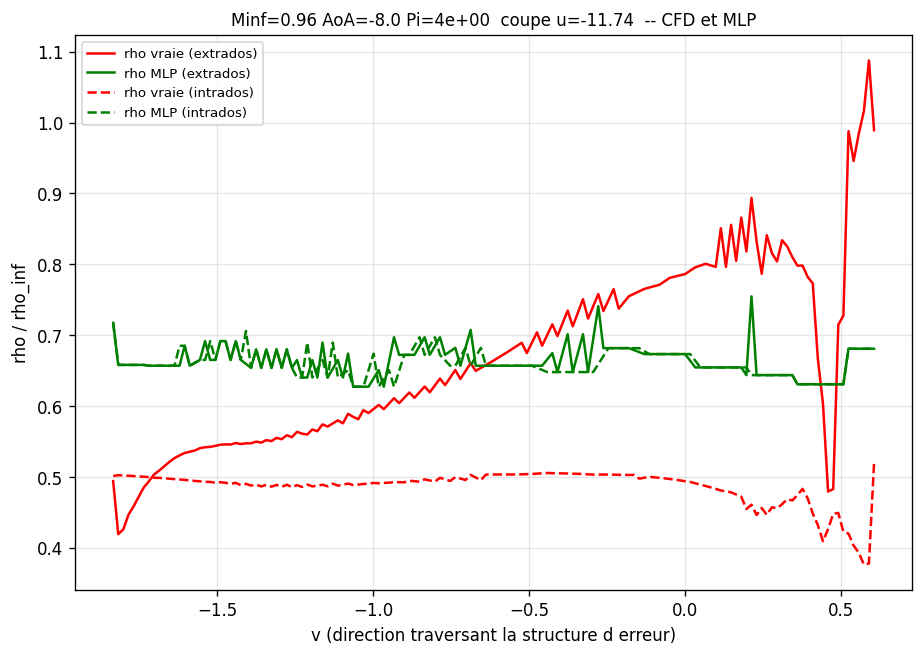

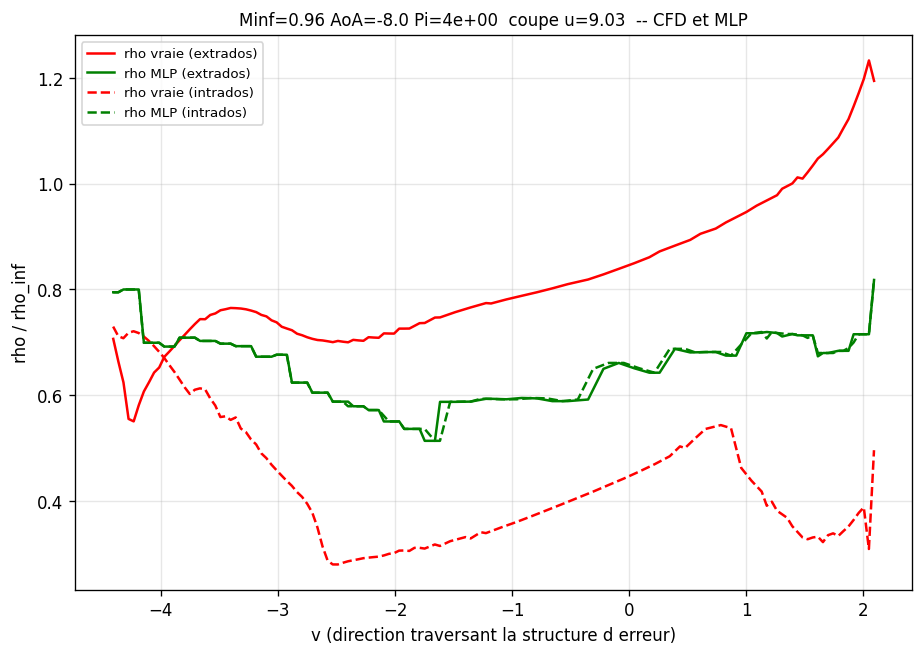

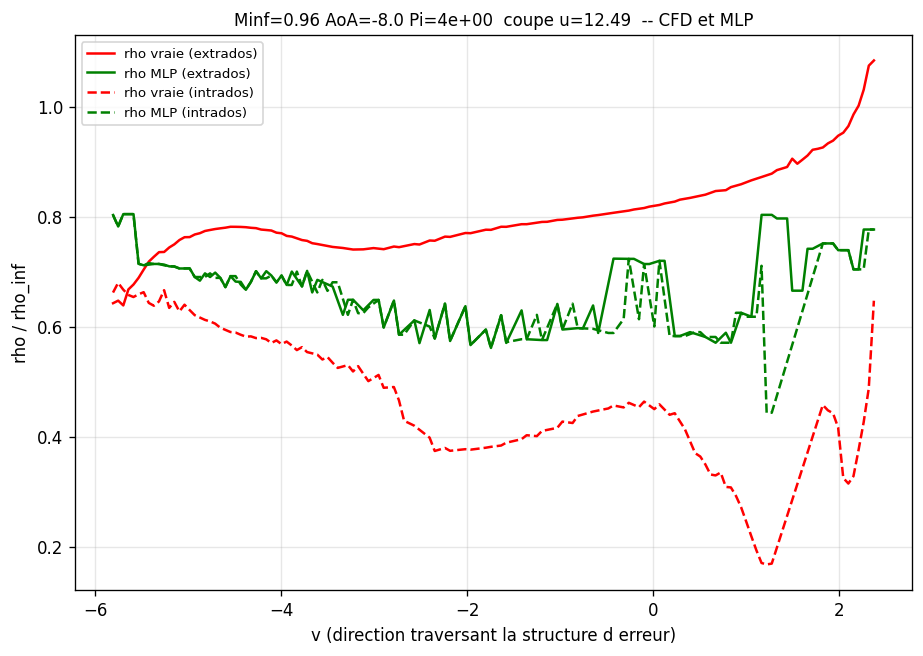

In [59]:

isim_worst = int(np.nanargmax(np.where(test2_weights == 1.0,
                                       res2['kl'], np.nan)))
print(f'pire sim KL phase 2: {isim_worst}  '
      f'Minf={test2_conds[isim_worst, 0]:.2f}  '
      f'AoA={test2_conds[isim_worst, 1]:.1f}  '
      f'Pi={test2_conds[isim_worst, 2]:.0e}  '
      f'KL={res2["kl"][isim_worst]:.4f}')

analyse_coupes_auto(isim_worst, X_test2, y_test2, y_pred2, 'wing',
                    'Phase 2', model_name='MLP', n_slices=3)

In [53]:
res2['kl'].shape

(57,)

pire sim KL phase 2: 39  Minf=0.96  AoA=-2.0  Pi=2e+00  KL=3.5567
coupes placees a u = ['-18.19', '3.97', '7.44']


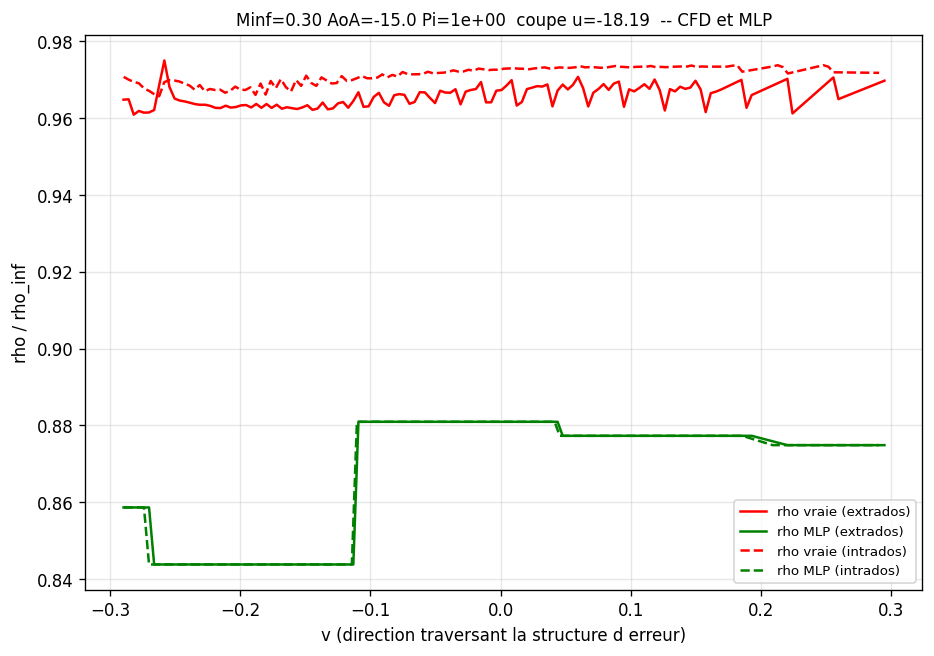

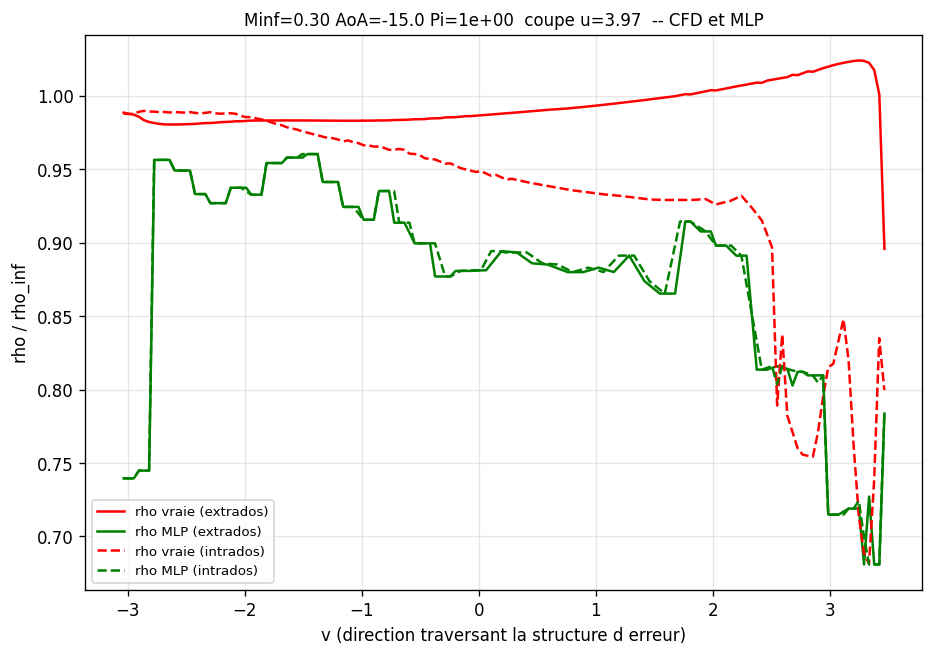

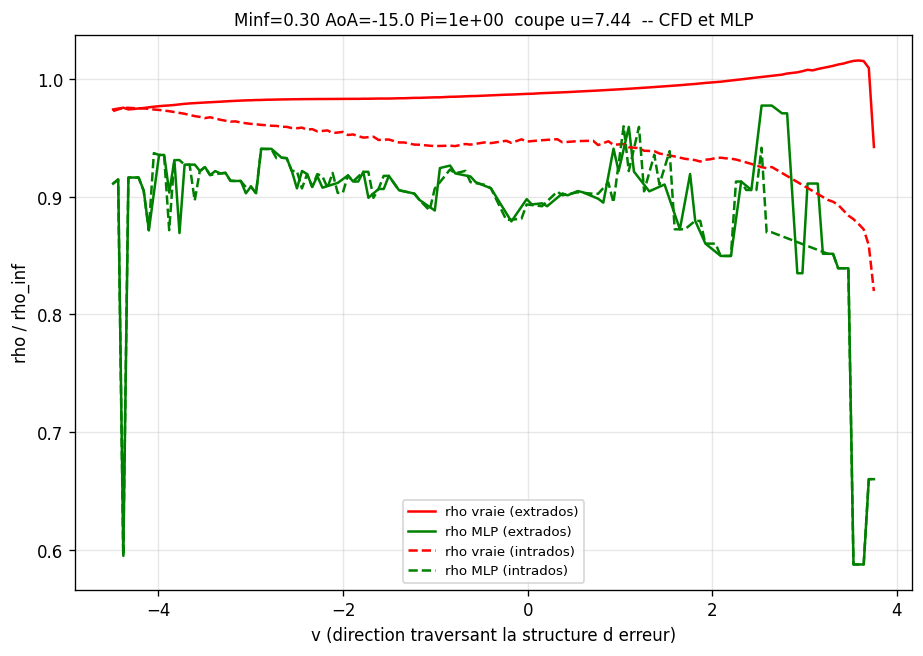

In [55]:
isim_worst = int(np.nanargmax(res2['kl']))


print(f'pire sim KL phase 2: {isim_worst}  '
      f'Minf={test2_conds[isim_worst, 0]:.2f}  '
      f'AoA={test2_conds[isim_worst, 1]:.1f}  '
      f'Pi={test2_conds[isim_worst, 2]:.0e}  '
      f'KL={res2["kl"][isim_worst]:.4f}')

analyse_coupes_auto(0, X_test2, y_test2, y_pred2, 'wing',
                    'Phase 2', model_name='MLP', n_slices=3)

La ou il y a le plus de variation sur rho mais pas sur l'erreur

In [60]:
def auto_slice_positions_rho(uv, yt, upper, n_slices=3, n_u=100, n_v=150,
                             min_separation=None, edge_frac=0.05):
    u, v = uv[:, 0], uv[:, 1]
    ue = np.linspace(u.min(), u.max(), n_u + 1)
    ve = np.linspace(v.min(), v.max(), n_v + 1)
    ui = np.clip(np.digitize(u, ue) - 1, 0, n_u - 1)
    vi = np.clip(np.digitize(v, ve) - 1, 0, n_v - 1)

    score = np.zeros(n_u)
    for face_mask in (upper, ~upper):
        cell = ui[face_mask] * n_v + vi[face_mask]
        sums = np.bincount(cell, weights=yt[face_mask], minlength=n_u * n_v)
        cnts = np.bincount(cell, minlength=n_u * n_v)
        grid = np.full(n_u * n_v, np.nan)
        ok = cnts > 0
        grid[ok] = sums[ok] / cnts[ok]
        grid = grid.reshape(n_u, n_v)
        jump = np.abs(np.diff(grid, axis=1))
        col_score = np.where(np.all(np.isnan(jump), axis=1), 0.0,
                             np.nanmax(jump, axis=1))
        score = np.maximum(score, col_score)

    centers = 0.5 * (ue[:-1] + ue[1:])
    cnt_u = np.bincount(ui, minlength=n_u)
    lo, hi = np.quantile(u, [edge_frac, 1.0 - edge_frac])
    score[(centers < lo) | (centers > hi)] = 0.0
    score[cnt_u < np.median(cnt_u[cnt_u > 0]) * 0.3] = 0.0

    if min_separation is None:
        min_separation = (u.max() - u.min()) / 10

    positions = []
    remaining = score.copy()
    for _ in range(n_slices):
        if remaining.max() <= 0:
            break
        b = int(np.argmax(remaining))
        positions.append(centers[b])
        remaining[np.abs(centers - centers[b]) < min_separation] = 0.0
    return sorted(positions)

pire sim KL phase 2: 60  Minf=0.96  AoA=-8.0  Pi=4e+00  KL=13.3298
coupes placees a u = ['1.55', '5.70', '11.24']


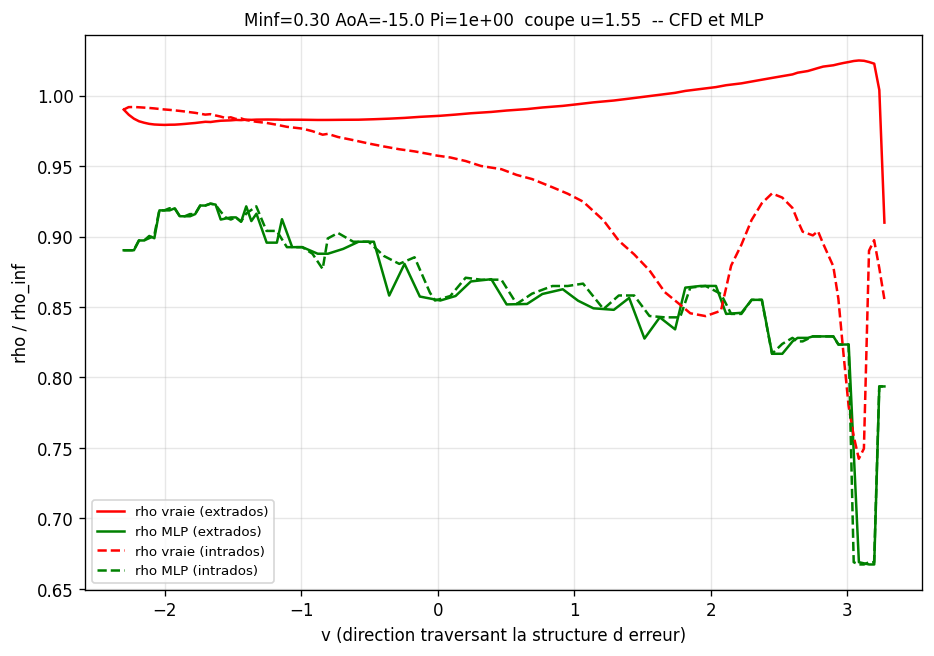

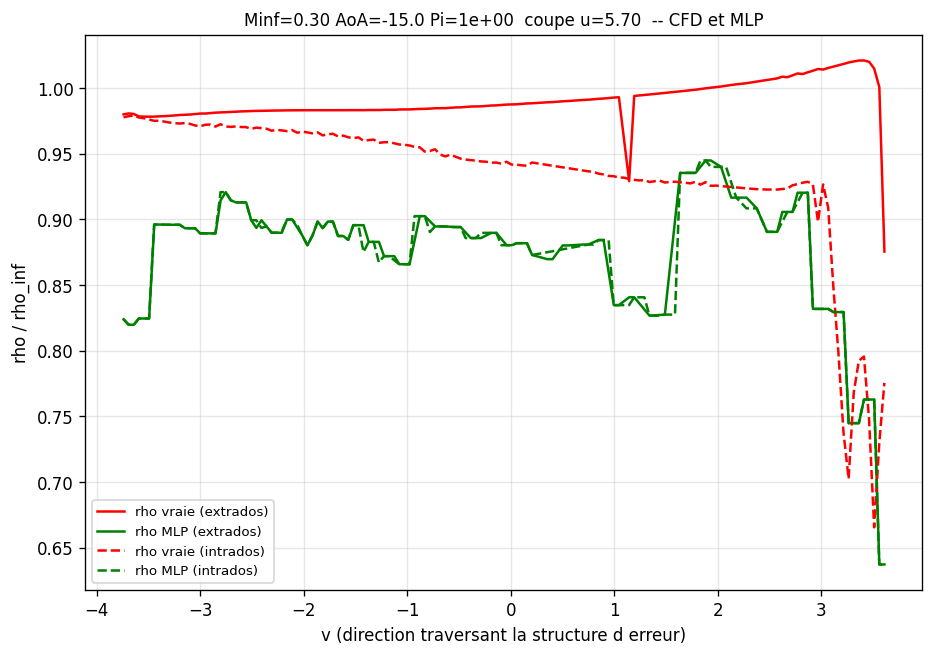

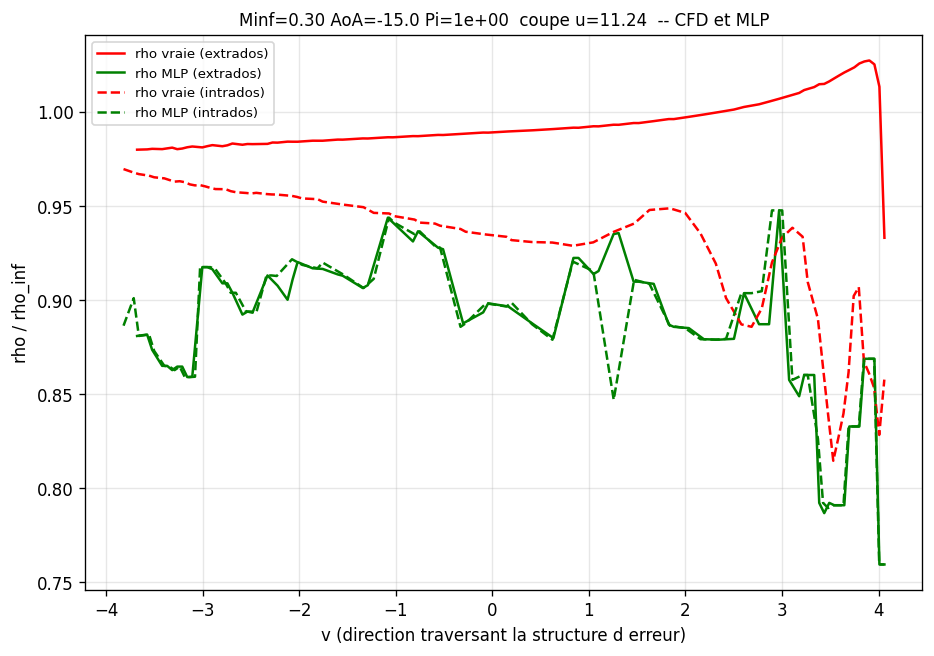

In [61]:
def analyse_coupes_auto(isim, X_test, y_test, y_pred, comp_name, phase_label,
                        model_name='model', n_slices=3, gamma=2.0):
    Xs = X_test[isim * nwallp:(isim + 1) * nwallp]
    ys = y_test[isim * nwallp:(isim + 1) * nwallp]
    yh = y_pred[isim * nwallp:(isim + 1) * nwallp]
    uv, yt, yp, err = error_pca_uv(Xs, ys, yh, comp_name, gamma=gamma)
    upper = (Xs[:, 5] >= 0.0)[comp_masks[comp_name]]

    span = uv[:, 0].max() - uv[:, 0].min()
    half_width = span / 200

    positions = auto_slice_positions_rho(uv, yt, upper, n_slices=n_slices)
    print(f'coupes placees a u = {[f"{p:.2f}" for p in positions]}')

    for u0 in positions:
        plot_slice_along_v(isim, X_test, y_test, y_pred, comp_name, u0, half_width,
                           phase_label, model_name=model_name, gamma=gamma,
                           uv_cache=(uv, yt, yp, err))
isim_worst = int(np.nanargmax(res2['kl']))


print(f'pire sim KL phase 2: {isim_worst}  '
      f'Minf={test2_conds[isim_worst, 0]:.2f}  '
      f'AoA={test2_conds[isim_worst, 1]:.1f}  '
      f'Pi={test2_conds[isim_worst, 2]:.0e}  '
      f'KL={res2["kl"][isim_worst]:.4f}')

analyse_coupes_auto(0, X_test2, y_test2, y_pred2, 'wing',
                    'Phase 2', model_name='MLP', n_slices=3)